# Product clustering in the complete daily dataset

This analysis uses `data/interim/transactions_dst_daily`. The clustering logic
is implemented in `src/data/preparation/discover_sparse_regions.py`; this notebook reads
its materialized product flags and diagnostics from `data/interim/product_sparse_regions`.

Product profiles use two observed behavior measures:

- demand frequency: positive product-store days / active product-store days;
- positive-day scale: kilograms / positive product-store days.

Closed Sundays and holidays are excluded only from the frequency denominator. No product
or product-store series is removed while the seven regions are discovered.


In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    (path.resolve() for path in [Path("../.."), Path(".."), Path(".")] if (path / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.common import read_parquet_expr
from src.data.preparation.discover_sparse_regions import (
    DIAGNOSTICS_PATH,
    IN_DIR as CLUSTER_DATA_DIR,
    REGION_FLAGS_PATH,
    SEGMENT_ORDER,
)

CLUSTER_GLOB = CLUSTER_DATA_DIR / "transactions_year_*.parquet"
for required_path in [REGION_FLAGS_PATH, DIAGNOSTICS_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing {required_path}. Run src/data/preparation/discover_sparse_regions.py first."
        )

con = duckdb.connect()
con.execute("PRAGMA threads=4")
cluster_source_expr = read_parquet_expr(CLUSTER_GLOB)
region_flags_expr = read_parquet_expr(REGION_FLAGS_PATH)
diagnostics_expr = read_parquet_expr(DIAGNOSTICS_PATH)

print(f"Raw profile source: {CLUSTER_GLOB}")
print(f"Materialized product regions: {REGION_FLAGS_PATH}")


Raw profile source: /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_dst_over_days/transactions_year_*.parquet
Materialized product regions: /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/product_sparse_regions/product_sparse_region_flags.parquet


### Vollständigkeit und Rohprofile

Die erste Tabelle auditiert den kompletten expandierten Datensatz. Die zweite Tabelle zeigt die vier fachlichen Segmente ohne Auswahl. Danach wird genau ein Profil pro Produkt gebildet. Unterschiedliche Historienlängen und Filialabdeckungen bleiben sichtbar und werden nicht als Ausschlusskriterium verwendet.

In [2]:
raw_cluster_audit = con.execute(f"""
SELECT
    COUNT(*)::BIGINT AS rows,
    COUNT_IF(is_active)::BIGINT AS active_rows,
    COUNT_IF(NOT is_active)::BIGINT AS closed_rows,
    COUNT_IF(is_fcm AND is_pseudo)::BIGINT AS overlapping_source_rows,
    COUNT_IF(NOT is_fcm AND NOT is_pseudo)::BIGINT AS unclassified_rows,
    COUNT(DISTINCT ARTIKEL_ID)::BIGINT AS products,
    COUNT(DISTINCT MARKT_ID)::BIGINT AS stores,
    MIN(CAST(DATE AS DATE)) AS first_date,
    MAX(CAST(DATE AS DATE)) AS data_end,
    (SELECT COUNT(*) FROM (
        SELECT ARTIKEL_ID, MARKT_ID, DATE
        FROM {cluster_source_expr}
        GROUP BY ALL HAVING COUNT(*) > 1
    ))::BIGINT AS duplicate_series_dates
FROM {cluster_source_expr}
""").fetchdf()
display(raw_cluster_audit)

if raw_cluster_audit.loc[0, [
    "overlapping_source_rows", "unclassified_rows", "duplicate_series_dates"
]].sum() != 0:
    raise RuntimeError("Raw cluster source audit failed")

raw_segment_coverage = con.execute(f"""
SELECT
    CASE WHEN is_fcm THEN 'FCM' ELSE 'Pseudo' END || ' ' || WGR_ID AS segment,
    COUNT(*)::BIGINT AS rows,
    COUNT_IF(is_active)::BIGINT AS active_rows,
    COUNT_IF(is_active AND ABVERKAUFTE_MENGE_KG > 0)::BIGINT AS demand_rows,
    COUNT(DISTINCT ARTIKEL_ID)::BIGINT AS products,
    COUNT(DISTINCT MARKT_ID)::BIGINT AS stores,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID))::BIGINT AS series,
    SUM(ABVERKAUFTE_MENGE_KG)::DOUBLE AS total_demand_kg
FROM {cluster_source_expr}
GROUP BY is_fcm, WGR_ID
ORDER BY CASE WHEN is_fcm THEN 1 ELSE 2 END, WGR_ID
""").fetchdf()
raw_segment_coverage["segment"] = pd.Categorical(
    raw_segment_coverage["segment"], SEGMENT_ORDER, ordered=True
)
display(raw_segment_coverage.sort_values("segment").style.format({
    "rows": "{:,.0f}", "active_rows": "{:,.0f}", "demand_rows": "{:,.0f}",
    "products": "{:,.0f}", "stores": "{:,.0f}", "series": "{:,.0f}",
    "total_demand_kg": "{:,.1f}",
}))

raw_product_profiles = con.execute(
    f"SELECT * FROM {region_flags_expr} ORDER BY segment, ARTIKEL_ID"
).fetchdf()
raw_product_profiles["segment_k2_cluster"] = raw_product_profiles[
    "intensity_cluster"
].map({"low_intensity": "lower_intensity", "high_intensity": "higher_intensity"})
raw_product_profiles["segment"] = pd.Categorical(
    raw_product_profiles["segment"], SEGMENT_ORDER, ordered=True
)

region_flag_columns = [
    "is_pseudo_890_high_velocity", "is_pseudo_890_low_velocity",
    "is_fcm_890", "is_fcm_900_low_intensity",
    "is_fcm_900_high_intensity", "is_pseudo_900_high_intensity",
    "is_pseudo_900_low_intensity",
]
assert len(raw_product_profiles) == raw_cluster_audit.loc[0, "products"]
assert raw_product_profiles["ARTIKEL_ID"].is_unique
assert raw_product_profiles[region_flag_columns].sum(axis=1).eq(1).all()
sparse_scale_outlier = raw_product_profiles["is_pseudo_890_sparse_scale_outlier"]
assert sparse_scale_outlier.sum() == 2
assert raw_product_profiles.loc[sparse_scale_outlier, "exclude_from_daily"].all()

raw_segment_profile_summary = (
    raw_product_profiles.groupby("segment", observed=True)
    .agg(
        products=("ARTIKEL_ID", "size"), stores_median=("stores", "median"),
        frequency_q25=("demand_frequency", lambda values: values.quantile(0.25)),
        frequency_median=("demand_frequency", "median"),
        frequency_q75=("demand_frequency", lambda values: values.quantile(0.75)),
        scale_q25=("kg_per_demand_day", lambda values: values.quantile(0.25)),
        scale_median=("kg_per_demand_day", "median"),
        scale_q75=("kg_per_demand_day", lambda values: values.quantile(0.75)),
        intensity_median=("kg_per_active_day", "median"),
    ).reset_index()
)
display(raw_segment_profile_summary.style.format({
    "products": "{:,.0f}", "stores_median": "{:,.1f}",
    "frequency_q25": "{:.1%}", "frequency_median": "{:.1%}",
    "frequency_q75": "{:.1%}", "scale_q25": "{:.3f}",
    "scale_median": "{:.3f}", "scale_q75": "{:.3f}",
    "intensity_median": "{:.3f}",
}))


,rows,active_rows,closed_rows,overlapping_source_rows,unclassified_rows,products,stores,first_date,data_end,duplicate_series_dates
0,53622235,44525414,9096821,0,0,681,213,2023-07-22,2026-07-21,0


,segment,rows,active_rows,demand_rows,products,stores,series,total_demand_kg
0,FCM 890,"530,933","439,092","26,391",23,198,"2,531","37,043.5"
1,FCM 900,"1,265,201","1,050,022","343,758",25,200,"4,201","163,286.1"
2,Pseudo 890,"51,232,387","42,543,303","6,942,573",553,210,"58,143","22,779,440.0"
3,Pseudo 900,"593,714","492,997","32,637",80,199,"1,358","16,599.5"


,segment,products,stores_median,frequency_q25,frequency_median,frequency_q75,scale_q25,scale_median,scale_q75,intensity_median
0,FCM 890,23,141.0,1.0%,3.6%,7.0%,1.000,1.375,1.774,0.051
1,FCM 900,25,183.0,15.1%,34.7%,42.2%,0.288,0.422,0.782,0.107
2,Pseudo 890,553,119.0,0.8%,3.5%,14.3%,0.646,0.970,1.746,0.036
3,Pseudo 900,80,1.0,0.3%,1.8%,6.5%,0.166,0.329,1.000,0.006


### Clusterdiagnostik ohne Vorfilter

Die Nachfragehäufigkeit wird per Logit und die positive Tagesmenge per `log1p` transformiert; anschließend werden beide Merkmale robust skaliert. Das verhindert, dass Einheiten oder stark schiefe Verteilungen die euklidische Distanz dominieren.

Zuerst wird eine globale Clusterung über alle 681 Produkte geprüft. Danach wird innerhalb jedes der vier fachlichen Segmente separat für `k = 2, …, 6` gerechnet. Berichtet werden Silhouette, Davies-Bouldin, Clustergrößen und die kleinste Gruppe. Es gibt keine Mindestgröße und keine automatische Produktentfernung.

In [3]:
all_cluster_diagnostics = con.execute(
    f"SELECT * FROM {diagnostics_expr} ORDER BY scope, k"
).fetchdf()
global_cluster_diagnostics = all_cluster_diagnostics[
    all_cluster_diagnostics["scope"] == "All products"
]
segment_cluster_diagnostics = all_cluster_diagnostics[
    all_cluster_diagnostics["scope"].isin(SEGMENT_ORDER)
]
display(global_cluster_diagnostics.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "smallest_cluster": "{:,.0f}",
}))
display(segment_cluster_diagnostics.style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "smallest_cluster": "{:,.0f}",
}))

segment_assignments = raw_product_profiles.copy()
segment_k2_summary = (
    segment_assignments.groupby(
        ["segment", "segment_k2_cluster"], observed=True
    ).agg(
        products=("ARTIKEL_ID", "size"), stores_median=("stores", "median"),
        frequency_median=("demand_frequency", "median"),
        scale_median=("kg_per_demand_day", "median"),
        intensity_median=("kg_per_active_day", "median"),
        total_demand_kg=("total_demand_kg", "sum"),
    ).reset_index()
)
display(segment_k2_summary.style.format({
    "products": "{:,.0f}", "stores_median": "{:,.1f}",
    "frequency_median": "{:.1%}", "scale_median": "{:.3f}",
    "intensity_median": "{:.3f}", "total_demand_kg": "{:,.1f}",
}))


,scope,k,silhouette,davies_bouldin,smallest_cluster,cluster_sizes
0,All products,2,0.860,0.146,8,"8, 673"
1,All products,3,0.525,0.553,8,"8, 136, 537"
2,All products,4,0.384,0.740,8,"8, 119, 249, 305"
3,All products,5,0.386,0.716,8,"8, 68, 159, 197, 249"
4,All products,6,0.356,0.778,8,"8, 57, 109, 154, 172, 181"
5,All products,7,0.356,0.797,8,"8, 44, 84, 108, 136, 141, 160"
6,All products,8,0.358,0.809,8,"8, 30, 64, 78, 88, 93, 152, 168"


,scope,k,silhouette,davies_bouldin,smallest_cluster,cluster_sizes
7,FCM 890,2,0.485,0.593,3,"3, 20"
8,FCM 890,3,0.475,0.548,3,"3, 4, 16"
9,FCM 890,4,0.497,0.704,3,"3, 4, 4, 12"
10,FCM 890,5,0.449,0.603,1,"1, 3, 4, 6, 9"
11,FCM 890,6,0.437,0.583,1,"1, 3, 4, 4, 5, 6"
12,FCM 900,2,0.721,0.290,5,"5, 20"
13,FCM 900,3,0.489,0.799,5,"5, 7, 13"
14,FCM 900,4,0.511,0.669,5,"5, 5, 6, 9"
15,FCM 900,5,0.550,0.560,3,"3, 5, 5, 5, 7"
16,FCM 900,6,0.583,0.542,2,"2, 3, 4, 5, 5, 6"


,segment,segment_k2_cluster,products,stores_median,frequency_median,scale_median,intensity_median,total_demand_kg
0,FCM 890,higher_intensity,3,161.0,22.5%,0.407,0.078,"1,030.9"
1,FCM 890,lower_intensity,20,139.5,2.7%,1.405,0.046,"36,012.7"
2,FCM 900,higher_intensity,20,189.0,37.3%,0.378,0.131,"161,498.8"
3,FCM 900,lower_intensity,5,107.0,1.0%,1.316,0.013,"1,787.4"
4,Pseudo 890,higher_intensity,119,197.0,19.8%,3.401,0.679,"20,596,974.3"
5,Pseudo 890,lower_intensity,434,73.5,2.3%,0.831,0.019,"2,182,465.8"
6,Pseudo 900,higher_intensity,6,1.0,0.3%,200.000,0.518,"1,400.0"
7,Pseudo 900,lower_intensity,74,1.5,2.4%,0.267,0.005,"15,199.5"


In [4]:
pseudo_890_assignments = segment_assignments[
    segment_assignments["segment"] == "Pseudo 890"
].copy()
pseudo_890_assignments["behavior_cluster"] = pseudo_890_assignments["region"].map({
    "pseudo_890_low_velocity": "lower_velocity",
    "pseudo_890_high_velocity": "higher_velocity",
})
pseudo_890_cluster_summary = (
    pseudo_890_assignments.groupby("behavior_cluster")
    .agg(
        products=("ARTIKEL_ID", "size"), stores_median=("stores", "median"),
        frequency_median=("demand_frequency", "median"),
        scale_median=("kg_per_demand_day", "median"),
        intensity_median=("kg_per_active_day", "median"),
        total_demand_kg=("total_demand_kg", "sum"),
    ).reset_index()
)
pseudo_890_cluster_summary["demand_share"] = (
    pseudo_890_cluster_summary["total_demand_kg"]
    / pseudo_890_cluster_summary["total_demand_kg"].sum()
)
display(pseudo_890_cluster_summary.style.format({
    "products": "{:,.0f}", "stores_median": "{:,.1f}",
    "frequency_median": "{:.1%}", "scale_median": "{:.3f}",
    "intensity_median": "{:.3f}", "total_demand_kg": "{:,.1f}",
    "demand_share": "{:.1%}",
}))

pseudo_900_high_examples = segment_assignments[
    segment_assignments["region"] == "pseudo_900_high_intensity"
][[
    "ARTIKEL_ID", "ARTIKEL_BEZ", "stores", "active_store_days",
    "demand_store_days", "demand_frequency", "kg_per_demand_day",
    "kg_per_active_day", "total_demand_kg",
]]
display(pseudo_900_high_examples.style.format({
    "stores": "{:,.0f}", "active_store_days": "{:,.0f}",
    "demand_store_days": "{:,.0f}", "demand_frequency": "{:.2%}",
    "kg_per_demand_day": "{:.3f}", "kg_per_active_day": "{:.3f}",
    "total_demand_kg": "{:,.1f}",
}))


,behavior_cluster,products,stores_median,frequency_median,scale_median,intensity_median,total_demand_kg,demand_share
0,higher_velocity,119,197.0,19.8%,3.401,0.679,"20,596,974.3",90.4%
1,lower_velocity,434,73.5,2.3%,0.831,0.019,"2,182,465.8",9.6%


,ARTIKEL_ID,ARTIKEL_BEZ,stores,active_store_days,demand_store_days,demand_frequency,kg_per_demand_day,kg_per_active_day,total_demand_kg
611,317409,Reinert Pfeffersalami,1,389,1,0.26%,200.000,0.514,200.0
614,317569,Reinert Parmesansalami,1,407,1,0.25%,200.000,0.491,200.0
615,317583,Metten Landrauch Cervelatwurst,1,419,1,0.24%,200.000,0.477,200.0
619,318313,Mortadella mit Paprika,1,429,2,0.47%,200.000,0.932,400.0
620,318327,Bley Schweinemettwurst Adewachter grob,1,383,1,0.26%,200.000,0.522,200.0
630,839494,Gutsleberwurst Fein,1,381,1,0.26%,200.000,0.525,200.0


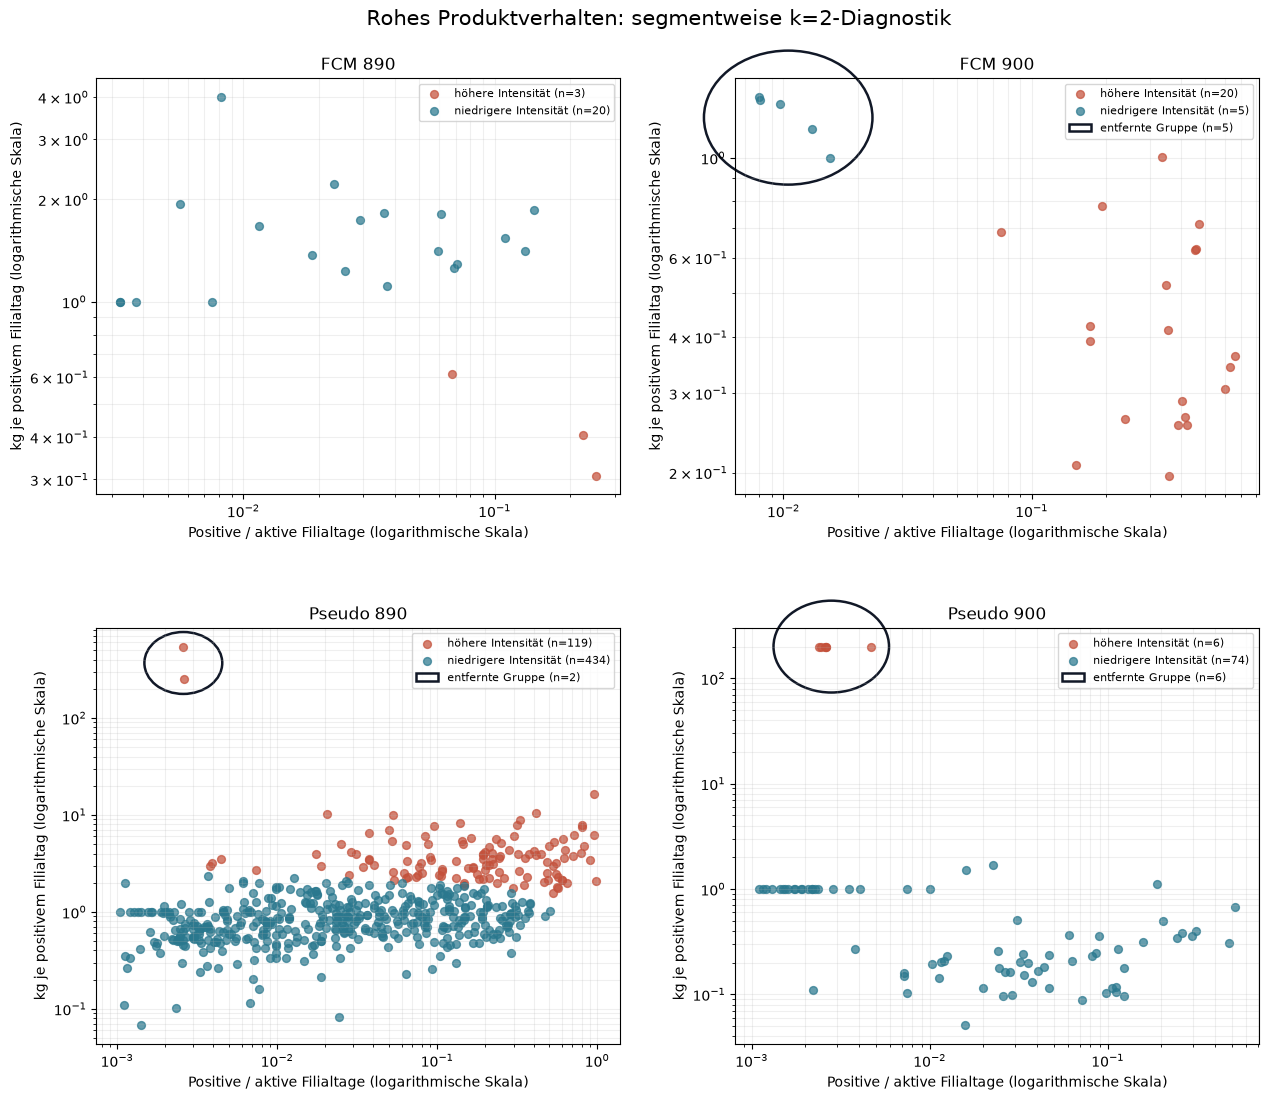

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11.5))
colors = {
    "lower_intensity": "#2a788e",
    "higher_intensity": "#c4513b",
}
CLUSTER_LABELS = {
    "lower_intensity": "niedrigere Intensität",
    "higher_intensity": "höhere Intensität",
}
for ax, segment in zip(axes.flat, SEGMENT_ORDER):
    values = segment_assignments[segment_assignments["segment"] == segment]
    for cluster_name, cluster_values in values.groupby("segment_k2_cluster"):
        ax.scatter(
            cluster_values["demand_frequency"],
            cluster_values["kg_per_demand_day"],
            s=32,
            alpha=0.72,
            color=colors[cluster_name],
            label=f"{CLUSTER_LABELS[cluster_name]} (n={len(cluster_values)})",
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    removed_values = values[values["exclude_from_daily"]]
    if not removed_values.empty:
        removed_xy = removed_values[[
            "demand_frequency", "kg_per_demand_day"
        ]].to_numpy()
        removed_axes_xy = ax.transAxes.inverted().transform(
            ax.transData.transform(removed_xy)
        )
        circle_center = removed_axes_xy.mean(axis=0)
        circle_radius = (
            np.linalg.norm(removed_axes_xy - circle_center, axis=1).max()
            + 0.035
        )
        ax.add_patch(plt.Circle(
            circle_center, circle_radius, transform=ax.transAxes,
            fill=False, edgecolor="#111827", linewidth=1.8,
            clip_on=False, label=f"entfernte Gruppe (n={len(removed_values)})",
        ))
    ax.set(
        title=segment,
        xlabel="Positive / aktive Filialtage (logarithmische Skala)",
        ylabel="kg je positivem Filialtag (logarithmische Skala)",
    )
    ax.grid(True, which="both", alpha=0.2)
    ax.legend(fontsize=8)
fig.suptitle("Rohes Produktverhalten: segmentweise k=2-Diagnostik", fontsize=15)
fig.subplots_adjust(bottom=0.08, top=0.92, hspace=0.32, wspace=0.22)
plt.show()

### Pseudo 890: high scale at very low frequency

Products `515828` and `388783` are explicit downstream exclusions because their only positive
store-day carries 544 kg and 250 kg respectively. They remain assigned to their original
Pseudo 890 behavior cluster, but the materialized view marks them with
`is_pseudo_890_sparse_scale_outlier`.

The dashed line marks 1% demand frequency. The four red points are the next four products with
the largest `kg_per_demand_day` to the left of that line; they are displayed as diagnostics and
are not filtered. The final panels show the two filtered products over the full dataset range.


,display_role,ARTIKEL_ID,ARTIKEL_BEZ,stores,active_store_days,demand_store_days,demand_frequency,kg_per_demand_day,kg_per_active_day,total_demand_kg
0,filtered,515828,US Entrecote ohne Kette,1,390,1,0.26%,544.000,1.395,544.000
1,filtered,388783,Rinderfilet argentinisch,1,381,1,0.26%,250.000,0.656,250.000
2,red diagnostic,993828,GV Gyrospfanne,2,"1,348",6,0.45%,3.476,0.015,20.854
3,red diagnostic,1222775,Gewürzbraten vom Rind aus der Keule,50,"28,380",112,0.39%,3.226,0.013,361.297
4,red diagnostic,1118880,Schinken Hamburger Rundschnitt,97,"59,610",228,0.38%,2.945,0.011,671.412
5,red diagnostic,1214993,Festtagsbraten,20,"17,174",127,0.74%,2.676,0.020,339.808


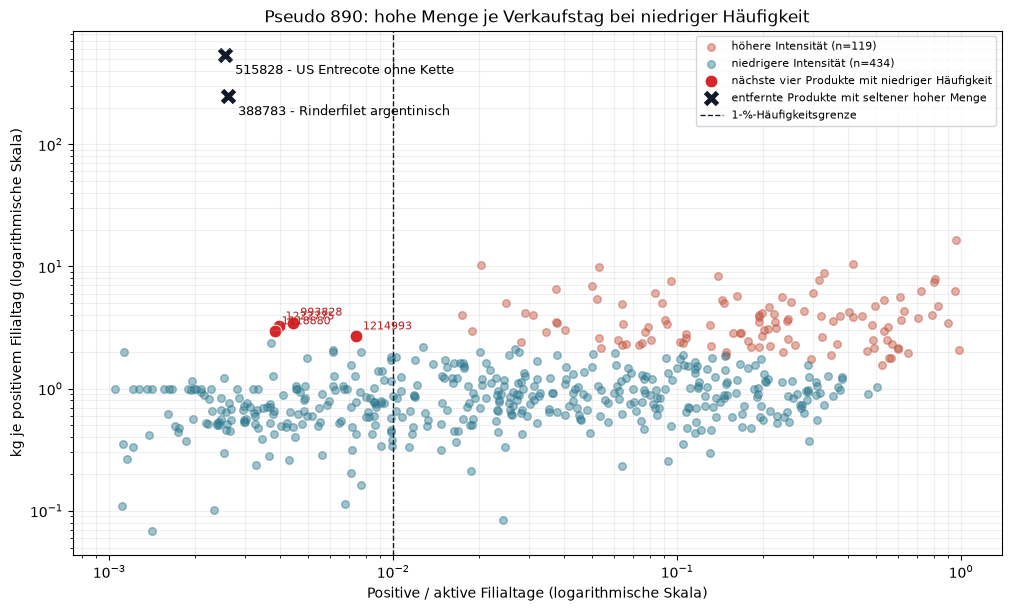

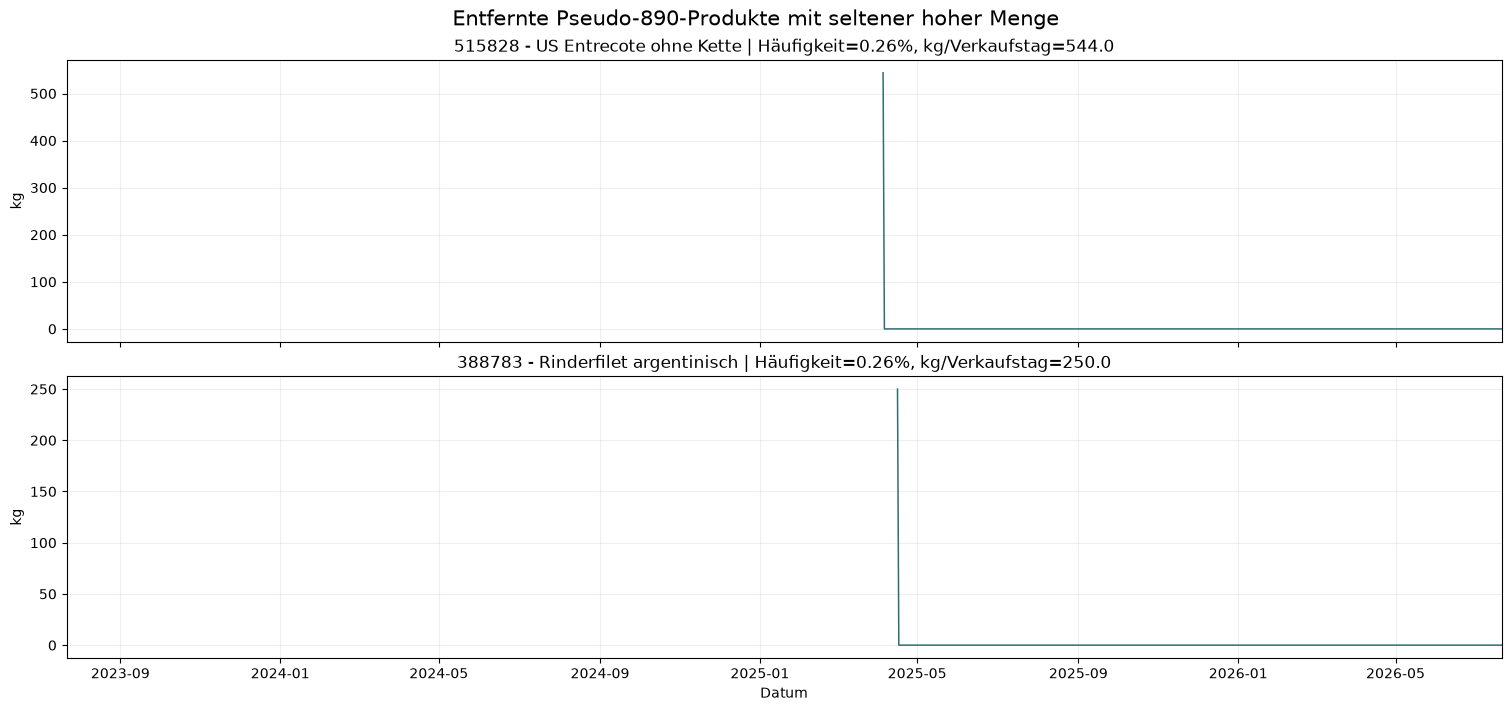

In [6]:
LOW_FREQUENCY_CUTOFF = 0.01
RED_DIAGNOSTIC_POINTS = 4

pseudo_890_values = segment_assignments[
    segment_assignments["segment"] == "Pseudo 890"
].copy()
pseudo_890_sparse_scale_products = (
    pseudo_890_values[
        pseudo_890_values["is_pseudo_890_sparse_scale_outlier"]
    ][[
        "ARTIKEL_ID", "ARTIKEL_BEZ", "region", "stores",
        "active_store_days", "demand_store_days", "demand_frequency",
        "kg_per_demand_day", "kg_per_active_day", "total_demand_kg",
        "exclusion_reason",
    ]]
    .sort_values("kg_per_demand_day", ascending=False)
    .reset_index(drop=True)
)
if len(pseudo_890_sparse_scale_products) != 2:
    raise RuntimeError(
        "Expected two materialized Pseudo 890 sparse-scale exclusions, found "
        f"{len(pseudo_890_sparse_scale_products)}"
    )

pseudo_890_red_diagnostics = (
    pseudo_890_values[
        (pseudo_890_values["demand_frequency"] < LOW_FREQUENCY_CUTOFF)
        & ~pseudo_890_values["is_pseudo_890_sparse_scale_outlier"]
    ]
    .nlargest(RED_DIAGNOSTIC_POINTS, "kg_per_demand_day")[[
        "ARTIKEL_ID", "ARTIKEL_BEZ", "region", "stores",
        "active_store_days", "demand_store_days", "demand_frequency",
        "kg_per_demand_day", "kg_per_active_day", "total_demand_kg",
    ]]
    .sort_values("kg_per_demand_day", ascending=False)
    .reset_index(drop=True)
)

display_products = pd.concat([
    pseudo_890_sparse_scale_products.assign(display_role="filtered"),
    pseudo_890_red_diagnostics.assign(display_role="red diagnostic"),
], ignore_index=True)
display(display_products[[
    "display_role", "ARTIKEL_ID", "ARTIKEL_BEZ", "stores",
    "active_store_days", "demand_store_days", "demand_frequency",
    "kg_per_demand_day", "kg_per_active_day", "total_demand_kg",
]].style.format({
    "stores": "{:,.0f}", "active_store_days": "{:,.0f}",
    "demand_store_days": "{:,.0f}", "demand_frequency": "{:.2%}",
    "kg_per_demand_day": "{:,.3f}", "kg_per_active_day": "{:,.3f}",
    "total_demand_kg": "{:,.3f}",
}))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for cluster_name, cluster_values in pseudo_890_values.groupby(
    "segment_k2_cluster"
):
    ax.scatter(
        cluster_values["demand_frequency"],
        cluster_values["kg_per_demand_day"],
        s=30, alpha=0.45, color=colors[cluster_name],
        label=f"{CLUSTER_LABELS[cluster_name]} (n={len(cluster_values)})",
    )
ax.scatter(
    pseudo_890_red_diagnostics["demand_frequency"],
    pseudo_890_red_diagnostics["kg_per_demand_day"],
    s=85, color="#d62728", edgecolor="white", linewidth=0.7,
    label="nächste vier Produkte mit niedriger Häufigkeit",
)
ax.scatter(
    pseudo_890_sparse_scale_products["demand_frequency"],
    pseudo_890_sparse_scale_products["kg_per_demand_day"],
    s=150, marker="X", color="#111827", edgecolor="white", linewidth=0.8,
    label="entfernte Produkte mit seltener hoher Menge",
)
for product in pseudo_890_sparse_scale_products.itertuples(index=False):
    ax.annotate(
        f"{product.ARTIKEL_ID} - {product.ARTIKEL_BEZ}",
        (product.demand_frequency, product.kg_per_demand_day),
        xytext=(7, -14), textcoords="offset points", fontsize=9,
    )
for product in pseudo_890_red_diagnostics.itertuples(index=False):
    ax.annotate(
        str(product.ARTIKEL_ID),
        (product.demand_frequency, product.kg_per_demand_day),
        xytext=(5, 5), textcoords="offset points", fontsize=8, color="#b91c1c",
    )
ax.axvline(
    LOW_FREQUENCY_CUTOFF, color="#111827", linestyle="--", linewidth=1,
    label="1-%-Häufigkeitsgrenze",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    title="Pseudo 890: hohe Menge je Verkaufstag bei niedriger Häufigkeit",
    xlabel="Positive / aktive Filialtage (logarithmische Skala)",
    ylabel="kg je positivem Filialtag (logarithmische Skala)",
)
ax.grid(True, which="both", alpha=0.2)
ax.legend(fontsize=8)
plt.show()

con.register(
    "pseudo_890_sparse_scale_ids",
    pseudo_890_sparse_scale_products[["ARTIKEL_ID"]],
)
pseudo_890_sparse_scale_daily = con.execute(f"""
SELECT
    CAST(t.DATE AS DATE) AS period,
    t.ARTIKEL_ID,
    SUM(t.ABVERKAUFTE_MENGE_KG)::DOUBLE AS demand_kg
FROM {cluster_source_expr} t
INNER JOIN pseudo_890_sparse_scale_ids p USING (ARTIKEL_ID)
GROUP BY period, t.ARTIKEL_ID
ORDER BY t.ARTIKEL_ID, period
""").fetchdf()

dataset_plot_start = pd.to_datetime(raw_cluster_audit.loc[0, "first_date"])
dataset_plot_end = pd.to_datetime(raw_cluster_audit.loc[0, "data_end"])
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True, constrained_layout=True)
for ax, product in zip(
    axes, pseudo_890_sparse_scale_products.itertuples(index=False)
):
    series = (
        pseudo_890_sparse_scale_daily[
            pseudo_890_sparse_scale_daily["ARTIKEL_ID"] == product.ARTIKEL_ID
        ]
        .set_index("period")["demand_kg"]
        .sort_index()
    )
    ax.plot(series.index, series.values, color="#2f6f73", linewidth=1.1)
    ax.set_xlim(dataset_plot_start, dataset_plot_end)
    ax.set_ylabel("kg")
    ax.set_title(
        f"{product.ARTIKEL_ID} - {product.ARTIKEL_BEZ} | "
        f"Häufigkeit={product.demand_frequency:.2%}, "
        f"kg/Verkaufstag={product.kg_per_demand_day:.1f}"
    )
    ax.grid(True, alpha=0.2)
axes[-1].set_xlabel("Datum")
fig.suptitle("Entfernte Pseudo-890-Produkte mit seltener hoher Menge", fontsize=15)
plt.show()


### Pseudo 890: time series of the four red diagnostic products

Daily kilograms are summed across stores for each product. The gray line shows the
daily total and the red line its 28-day rolling mean. All panels use the complete
dataset date range.


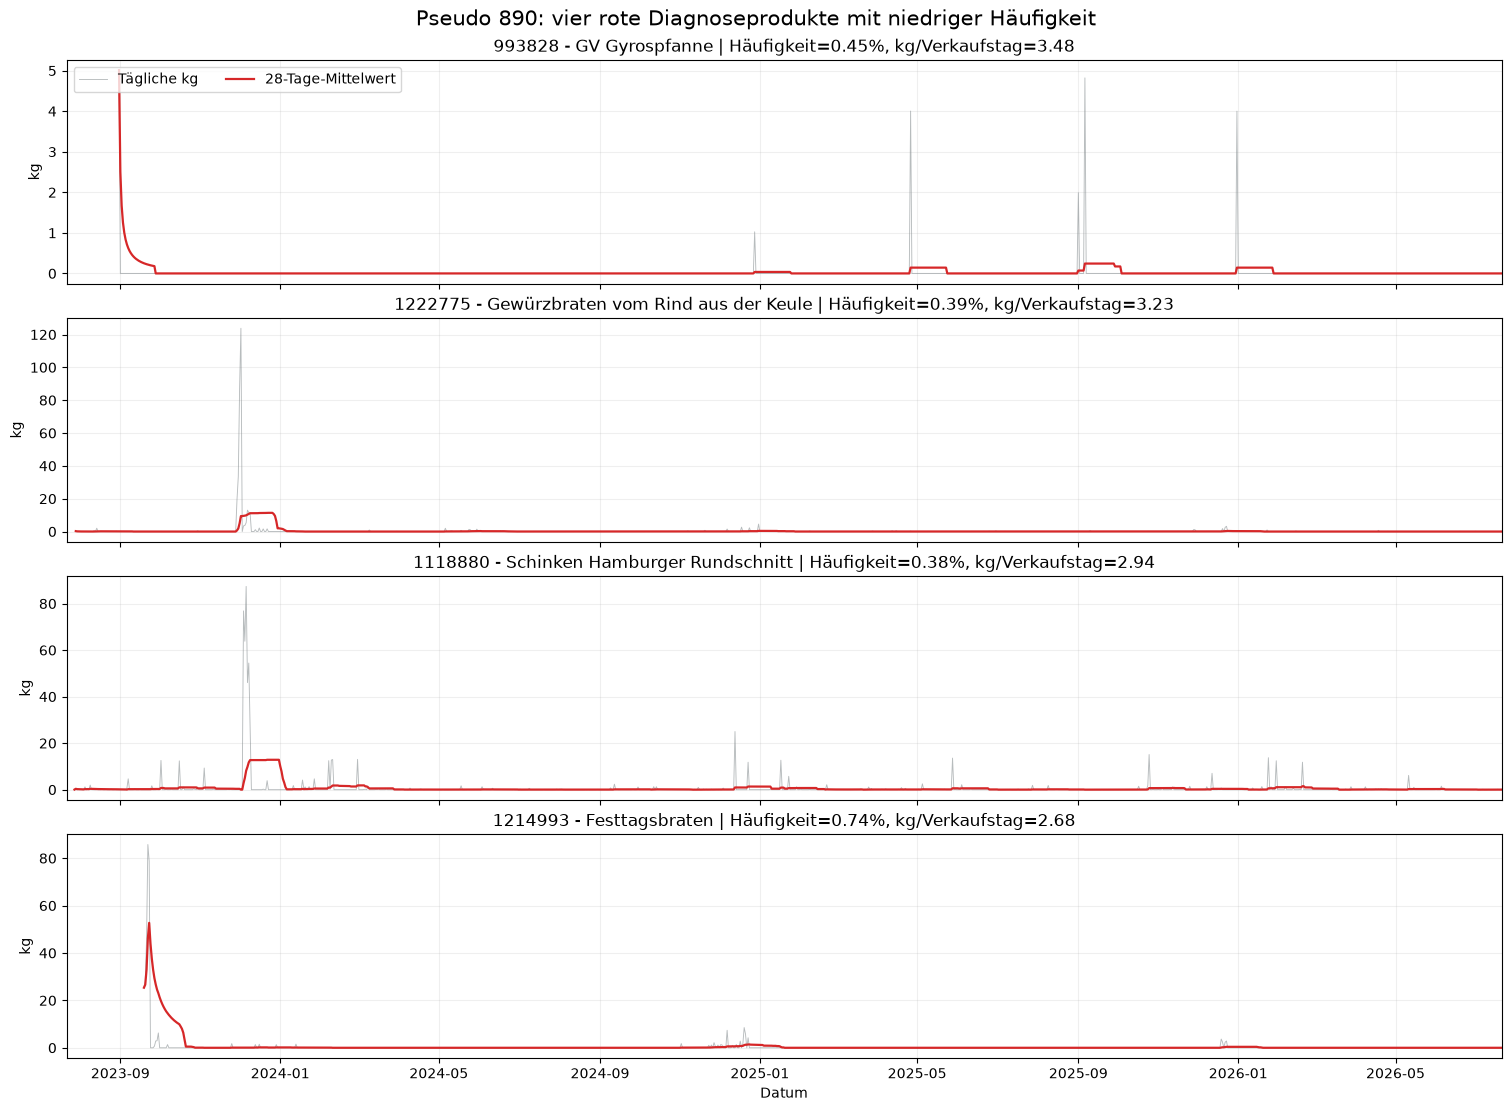

In [7]:
con.register(
    "pseudo_890_red_diagnostic_ids",
    pseudo_890_red_diagnostics[["ARTIKEL_ID"]],
)
pseudo_890_red_diagnostic_daily = con.execute(f"""
SELECT
    CAST(t.DATE AS DATE) AS period,
    t.ARTIKEL_ID,
    SUM(t.ABVERKAUFTE_MENGE_KG)::DOUBLE AS demand_kg
FROM {cluster_source_expr} t
INNER JOIN pseudo_890_red_diagnostic_ids p USING (ARTIKEL_ID)
GROUP BY period, t.ARTIKEL_ID
ORDER BY t.ARTIKEL_ID, period
""").fetchdf()

dataset_plot_start = pd.to_datetime(raw_cluster_audit.loc[0, "first_date"])
dataset_plot_end = pd.to_datetime(raw_cluster_audit.loc[0, "data_end"])
fig, axes = plt.subplots(
    len(pseudo_890_red_diagnostics),
    1,
    figsize=(15, 11),
    sharex=True,
    constrained_layout=True,
)
for ax, product in zip(
    axes, pseudo_890_red_diagnostics.itertuples(index=False)
):
    series = (
        pseudo_890_red_diagnostic_daily[
            pseudo_890_red_diagnostic_daily["ARTIKEL_ID"]
            == product.ARTIKEL_ID
        ]
        .set_index("period")["demand_kg"]
        .sort_index()
    )
    rolling_demand = series.rolling("28D", min_periods=1).mean()
    ax.plot(
        series.index, series.values,
        color="#7d8588", linewidth=0.65, alpha=0.55, label="Tägliche kg",
    )
    ax.plot(
        rolling_demand.index, rolling_demand.values,
        color="#d62728", linewidth=1.6, label="28-Tage-Mittelwert",
    )
    ax.set_xlim(dataset_plot_start, dataset_plot_end)
    ax.set_ylabel("kg")
    ax.set_title(
        f"{product.ARTIKEL_ID} - {product.ARTIKEL_BEZ} | "
        f"Häufigkeit={product.demand_frequency:.2%}, "
        f"kg/Verkaufstag={product.kg_per_demand_day:.2f}"
    )
    ax.grid(True, alpha=0.2)
axes[0].legend(loc="upper left", ncol=2)
axes[-1].set_xlabel("Datum")
fig.suptitle("Pseudo 890: vier rote Diagnoseprodukte mit niedriger Häufigkeit", fontsize=15)
plt.show()


In [8]:
# These assignments come directly from the materialized product-region view.
product_cluster_assignments = segment_assignments.copy()
product_cluster_assignments["recommended_group"] = product_cluster_assignments[
    "region"
].replace({
    "pseudo_890_low_velocity": "pseudo_890__lower_velocity",
    "pseudo_890_high_velocity": "pseudo_890__higher_velocity",
})

recommended_group_summary = (
    product_cluster_assignments.groupby("region")
    .agg(
        products=("ARTIKEL_ID", "size"),
        median_frequency=("demand_frequency", "median"),
        median_scale_kg=("kg_per_demand_day", "median"),
        median_intensity_kg=("kg_per_active_day", "median"),
        total_demand_kg=("total_demand_kg", "sum"),
        excluded_from_daily=("exclude_from_daily", "all"),
    ).reset_index()
)
display(recommended_group_summary.style.format({
    "products": "{:,.0f}", "median_frequency": "{:.1%}",
    "median_scale_kg": "{:.3f}", "median_intensity_kg": "{:.3f}",
    "total_demand_kg": "{:,.1f}",
}))


,region,products,median_frequency,median_scale_kg,median_intensity_kg,total_demand_kg,excluded_from_daily
0,fcm_890,23,3.6%,1.375,0.051,"37,043.5",False
1,fcm_900_high_intensity,20,37.3%,0.378,0.131,"161,498.8",False
2,fcm_900_low_intensity,5,1.0%,1.316,0.013,"1,787.4",True
3,pseudo_890_high_velocity,119,19.8%,3.401,0.679,"20,596,974.3",False
4,pseudo_890_low_velocity,434,2.3%,0.831,0.019,"2,182,465.8",False
5,pseudo_900_high_intensity,6,0.3%,200.000,0.518,"1,400.0",True
6,pseudo_900_low_intensity,74,2.4%,0.267,0.005,"15,199.5",False


### Interpretation and downstream decision

- **Pseudo 890:** the materialized `k = 2` split contains 434 lower-velocity and
  119 higher-velocity products. Both remain in the daily dataset as separate groups.
- **FCM 900:** 20 high-intensity products remain; the five low-intensity products are
  flagged for removal from `transactions_dst_daily_filtered`.
- **Pseudo 900:** the six high-intensity products are the one-store 200 kg pattern and
  are flagged for removal; the remaining 74 low-intensity products stay together.
- **FCM 890:** all 23 products remain one business group because its internal `k = 2`
  diagnostic is not used as a downstream split.

The `region` and boolean flag columns are materialized for all products. The notebook
does not fit or relabel clusters.


### FCM 900: Zeitreihen der Fünfergruppe

Die fünf Produkte des kleineren `k = 2`-Clusters werden ohne weitere Auswahl dargestellt. Die Tagesmenge ist über alle vorhandenen Filialen je Produkt summiert; die geglättete Linie zeigt den gleitenden 28-Tage-Mittelwert.

,ARTIKEL_ID,ARTIKEL_BEZ,stores,demand_frequency,kg_per_demand_day,kg_per_active_day,total_demand_kg
0,1401346,SB Rostbratwurst,93,0.81%,1.346,0.011,274.6
1,1402017,SB Bockwurst,109,1.30%,1.158,0.015,457.6
2,1402844,"SB Friesen Bratwurst, gebrüht",107,0.97%,1.316,0.013,371.1
3,1405612,SB Goldmarie Krakauer,103,0.80%,1.365,0.011,281.2
4,1407295,SB Mettenden,114,1.54%,0.998,0.015,403.0


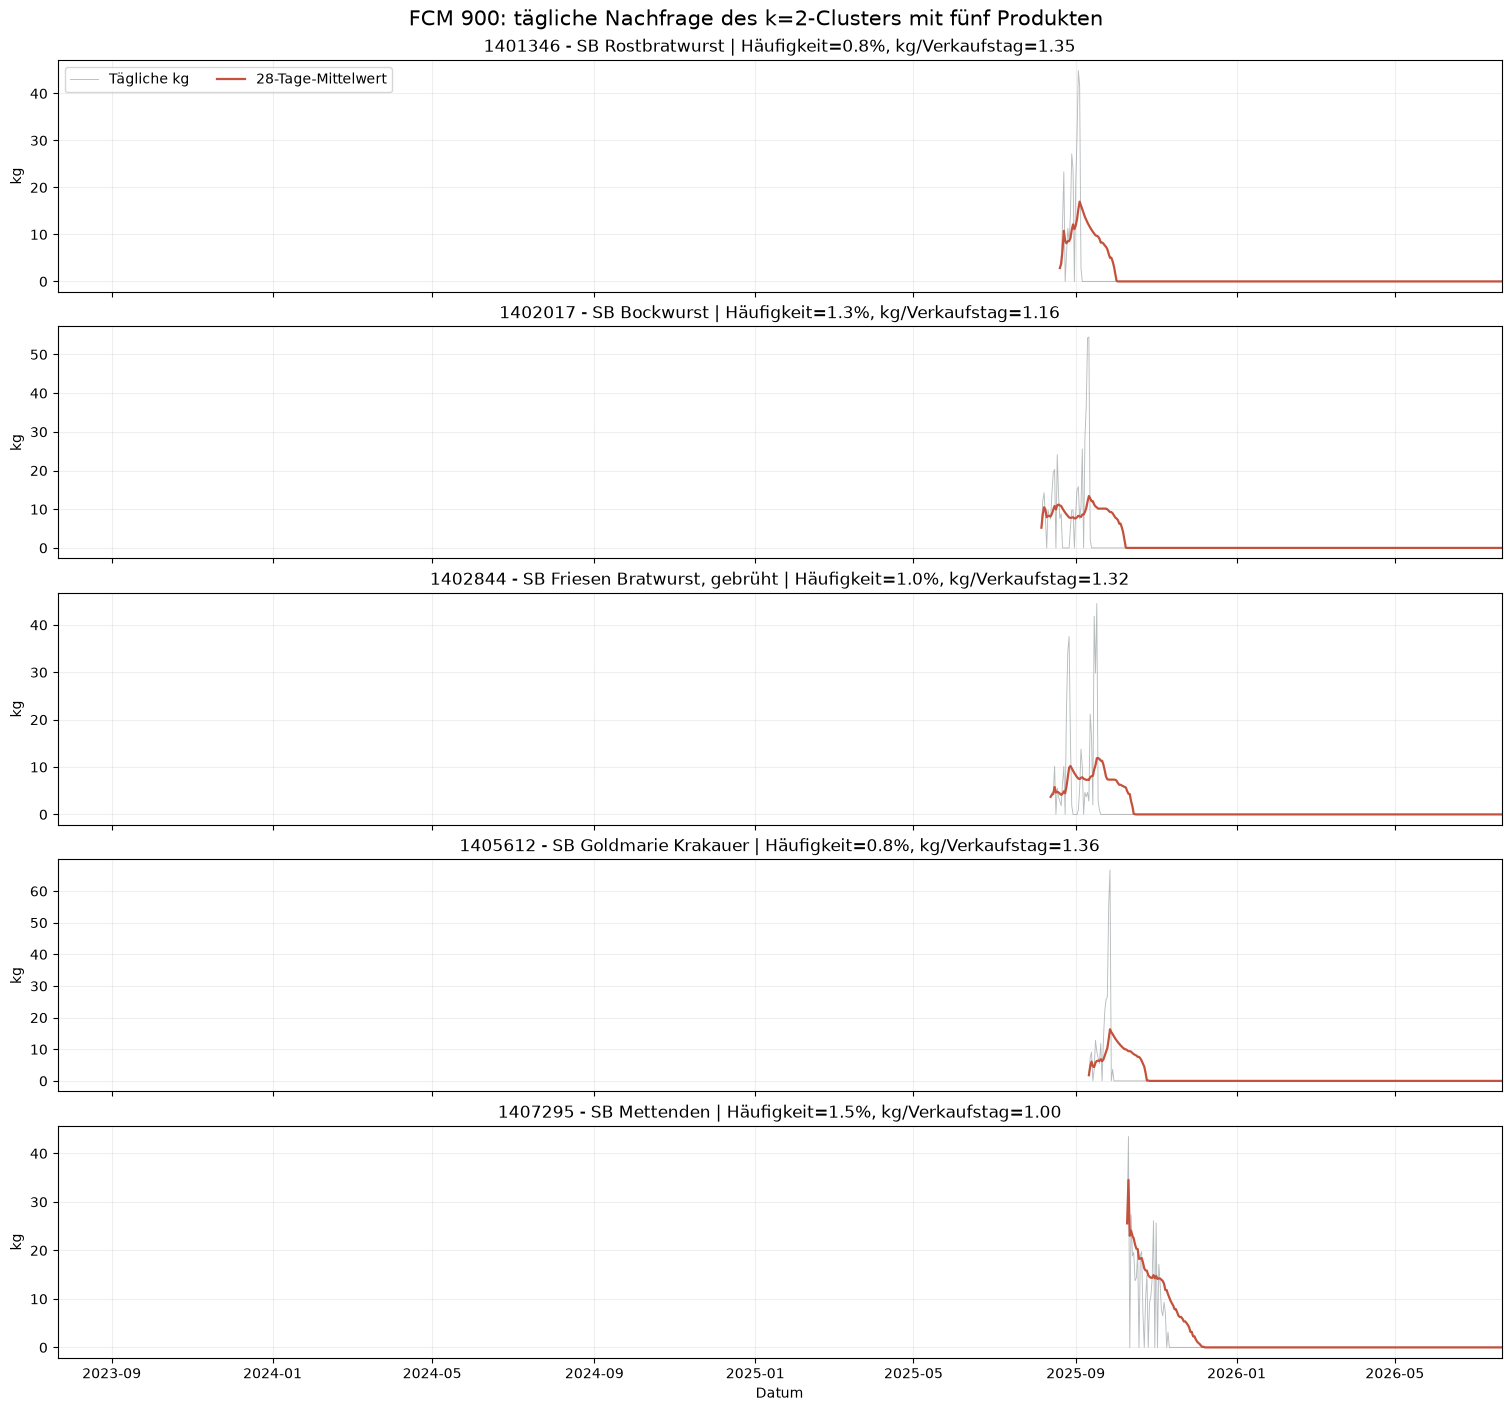

In [9]:
fcm_900_assignments = segment_assignments[
    segment_assignments["segment"] == "FCM 900"
].copy()
fcm_900_cluster_sizes = fcm_900_assignments.groupby(
    "segment_k2_cluster"
)["ARTIKEL_ID"].size()
five_product_labels = fcm_900_cluster_sizes[
    fcm_900_cluster_sizes == 5
].index.tolist()
if len(five_product_labels) != 1:
    raise RuntimeError(
        "Expected exactly one five-product FCM 900 cluster, found "
        f"{fcm_900_cluster_sizes.to_dict()}"
    )

fcm_900_five_products = (
    fcm_900_assignments[
        fcm_900_assignments["segment_k2_cluster"] == five_product_labels[0]
    ][[
        "ARTIKEL_ID", "ARTIKEL_BEZ", "stores", "demand_frequency",
        "kg_per_demand_day", "kg_per_active_day", "total_demand_kg",
    ]]
    .sort_values("ARTIKEL_ID")
    .reset_index(drop=True)
)
display(fcm_900_five_products.style.format({
    "stores": "{:,.0f}",
    "demand_frequency": "{:.2%}",
    "kg_per_demand_day": "{:.3f}",
    "kg_per_active_day": "{:.3f}",
    "total_demand_kg": "{:,.1f}",
}))

con.register(
    "fcm_900_five_product_ids",
    fcm_900_five_products[["ARTIKEL_ID"]],
)
fcm_900_five_daily = con.execute(f"""
SELECT
    CAST(t.DATE AS DATE) AS period,
    t.ARTIKEL_ID,
    ARG_MAX(t.ARTIKEL_BEZ, CAST(t.DATE AS DATE)) AS ARTIKEL_BEZ,
    SUM(t.ABVERKAUFTE_MENGE_KG)::DOUBLE AS demand_kg,
    COUNT(DISTINCT t.MARKT_ID) FILTER (WHERE t.is_active)::BIGINT
        AS active_stores
FROM {cluster_source_expr} t
INNER JOIN fcm_900_five_product_ids p USING (ARTIKEL_ID)
GROUP BY period, t.ARTIKEL_ID
ORDER BY t.ARTIKEL_ID, period
""").fetchdf()

dataset_plot_start = pd.to_datetime(raw_cluster_audit.loc[0, "first_date"])
dataset_plot_end = pd.to_datetime(raw_cluster_audit.loc[0, "data_end"])

fig, axes = plt.subplots(
    len(fcm_900_five_products),
    1,
    figsize=(15, 14),
    sharex=True,
    constrained_layout=True,
)
for ax, product in zip(axes, fcm_900_five_products.itertuples(index=False)):
    series = (
        fcm_900_five_daily[
            fcm_900_five_daily["ARTIKEL_ID"] == product.ARTIKEL_ID
        ]
        .set_index("period")["demand_kg"]
        .sort_index()
    )
    rolling_demand = series.rolling("28D", min_periods=1).mean()
    ax.plot(
        series.index,
        series.values,
        color="#7d8588",
        linewidth=0.65,
        alpha=0.55,
        label="Tägliche kg",
    )
    ax.plot(
        rolling_demand.index,
        rolling_demand.values,
        color="#c4513b",
        linewidth=1.6,
        label="28-Tage-Mittelwert",
    )
    ax.set_title(
        f"{product.ARTIKEL_ID} - {product.ARTIKEL_BEZ} | "
        f"Häufigkeit={product.demand_frequency:.1%}, "
        f"kg/Verkaufstag={product.kg_per_demand_day:.2f}"
    )
    ax.set_ylabel("kg")
    ax.grid(True, alpha=0.2)
axes[0].legend(loc="upper left", ncol=2)
axes[-1].set_xlim(dataset_plot_start, dataset_plot_end)
axes[-1].set_xlabel("Datum")
fig.suptitle(
    "FCM 900: tägliche Nachfrage des k=2-Clusters mit fünf Produkten",
    fontsize=15,
)
plt.show()